In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [2]:
BLUE_RANGE = (3300*u.AA, 3550*u.AA)
RED_RANGE = (4500*u.AA, 4750*u.AA)

In [3]:
def interp_wavelength_on_grids(flux_density, wavelengths,new_wavelength):
    if len(flux_density)!=len(wavelengths):
        raise ValueError("Length of flux_density and wavelengths must be the same.")
    if isinstance(new_wavelength, u.Quantity):
        new_wavelength = new_wavelength.to(u.AA).value
    else:
        new_wavelength = np.array(new_wavelength)

    if isinstance(wavelengths, u.Quantity):
        wavelengths = wavelengths.to(u.AA).value
    else:
        wavelengths = np.array(wavelengths)

    interp_func=interp1d(wavelengths, flux_density.data, kind='linear', bounds_error=False, fill_value=np.nan)
    new_flux_density=interp_func(new_wavelength)
    return new_flux_density*u.Unit(flux_density.unit)

In [5]:

flux_ratio=[]
survey_id_subid_list=[]
for survey_id_subid, catalog_entry in DJAv4Catalog.catalog_iterator():
    if not catalog_entry['sample_flag']:
        continue

    prism_spectrum=FL.Load_Spectrum_From_Fits(catalog_entry['prism_filepath'], catalog_entry['determined_redshift'])

    corrector=FL.CalzettiCorrector()

    halpha_flux=catalog_entry['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
    hbeta_flux=catalog_entry['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']

    corrected_spec=corrector.deredden_flux(prism_spectrum, ha_flux=halpha_flux, hb_flux=hbeta_flux)

    #interpolate to rest-frame 10AA bins

    rest_f_lambda=corrected_spec.restframe_flux_lambda.data*u.Unit(corrected_spec.restframe_flux_lambda.unit)
    rest_wave=(corrected_spec.restframe_wavelengths.data*u.um).to(u.AA)

    interp_wavelength=np.arange(3000,5000,10)*u.AA


    interp_f_lambda=interp_wavelength_on_grids(
        rest_f_lambda,
        rest_wave,
        interp_wavelength
    )

    blue_mask=(interp_wavelength>=BLUE_RANGE[0]) & (interp_wavelength<=BLUE_RANGE[1])
    red_mask=(interp_wavelength>=RED_RANGE[0]) & (interp_wavelength<=RED_RANGE[1])

    blue_flux_density=np.nanmean(interp_f_lambda[blue_mask])
    red_flux_density=np.nanmean(interp_f_lambda[red_mask])

    catalog_entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']={
        'blue_flux_density': blue_flux_density,
        'red_flux_density': red_flux_density
    }

    DJAv4Catalog.update_catalog_item(survey_id_subid, catalog_entry)

    flux_ratio.append(red_flux_density/blue_flux_density)
    survey_id_subid_list.append(survey_id_subid)



[1.58253976 1.57681799 1.57115756 1.56555739 1.56001645 1.55453373
 1.54910824 1.54373902 1.53842512 1.53316562 1.52795961 1.52280623
 1.51770459 1.51265387 1.50765324 1.5027019  1.49779905 1.49294393
 1.48813579 1.48337388 1.47865748 1.4739859  1.46935843 1.46477441
 1.46023316 1.45573405 1.45127643 1.44685968 1.44248319 1.43814638
 1.43384864 1.42958942 1.42536814 1.42118426 1.41703724 1.41292655
 1.40885167 1.4048121  1.40080733 1.39683688 1.39290027 1.38899703
 1.38512669 1.38128881 1.37748293 1.37370864 1.36996549 1.36625308
 1.36257098 1.3589188  1.35529613 1.35170259 1.3481378  1.34460138
 1.34109296 1.33761218 1.33415869 1.33073213 1.32733216 1.32395845
 1.32061066 1.31728847 1.31399156 1.31071961 1.30747232 1.30424938
 1.3010505  1.29787537 1.29472371 1.29159525 1.28848969 1.28540676
 1.2823462  1.27930773 1.27629111 1.27329607 1.27032235 1.26736971
 1.26443791 1.26152671 1.25863586 1.25576514 1.25291431 1.25008315
 1.24727144 1.24447896 1.24170549 1.23895083 1.23621475 1.2334

In [8]:
DJAv4Catalog.save_catalog_to_pkl('./DJAV4.2Catalog.pkl')

In [20]:
No_Correction=flux_ratio

In [9]:
Corrected_Flux_Ratio=flux_ratio

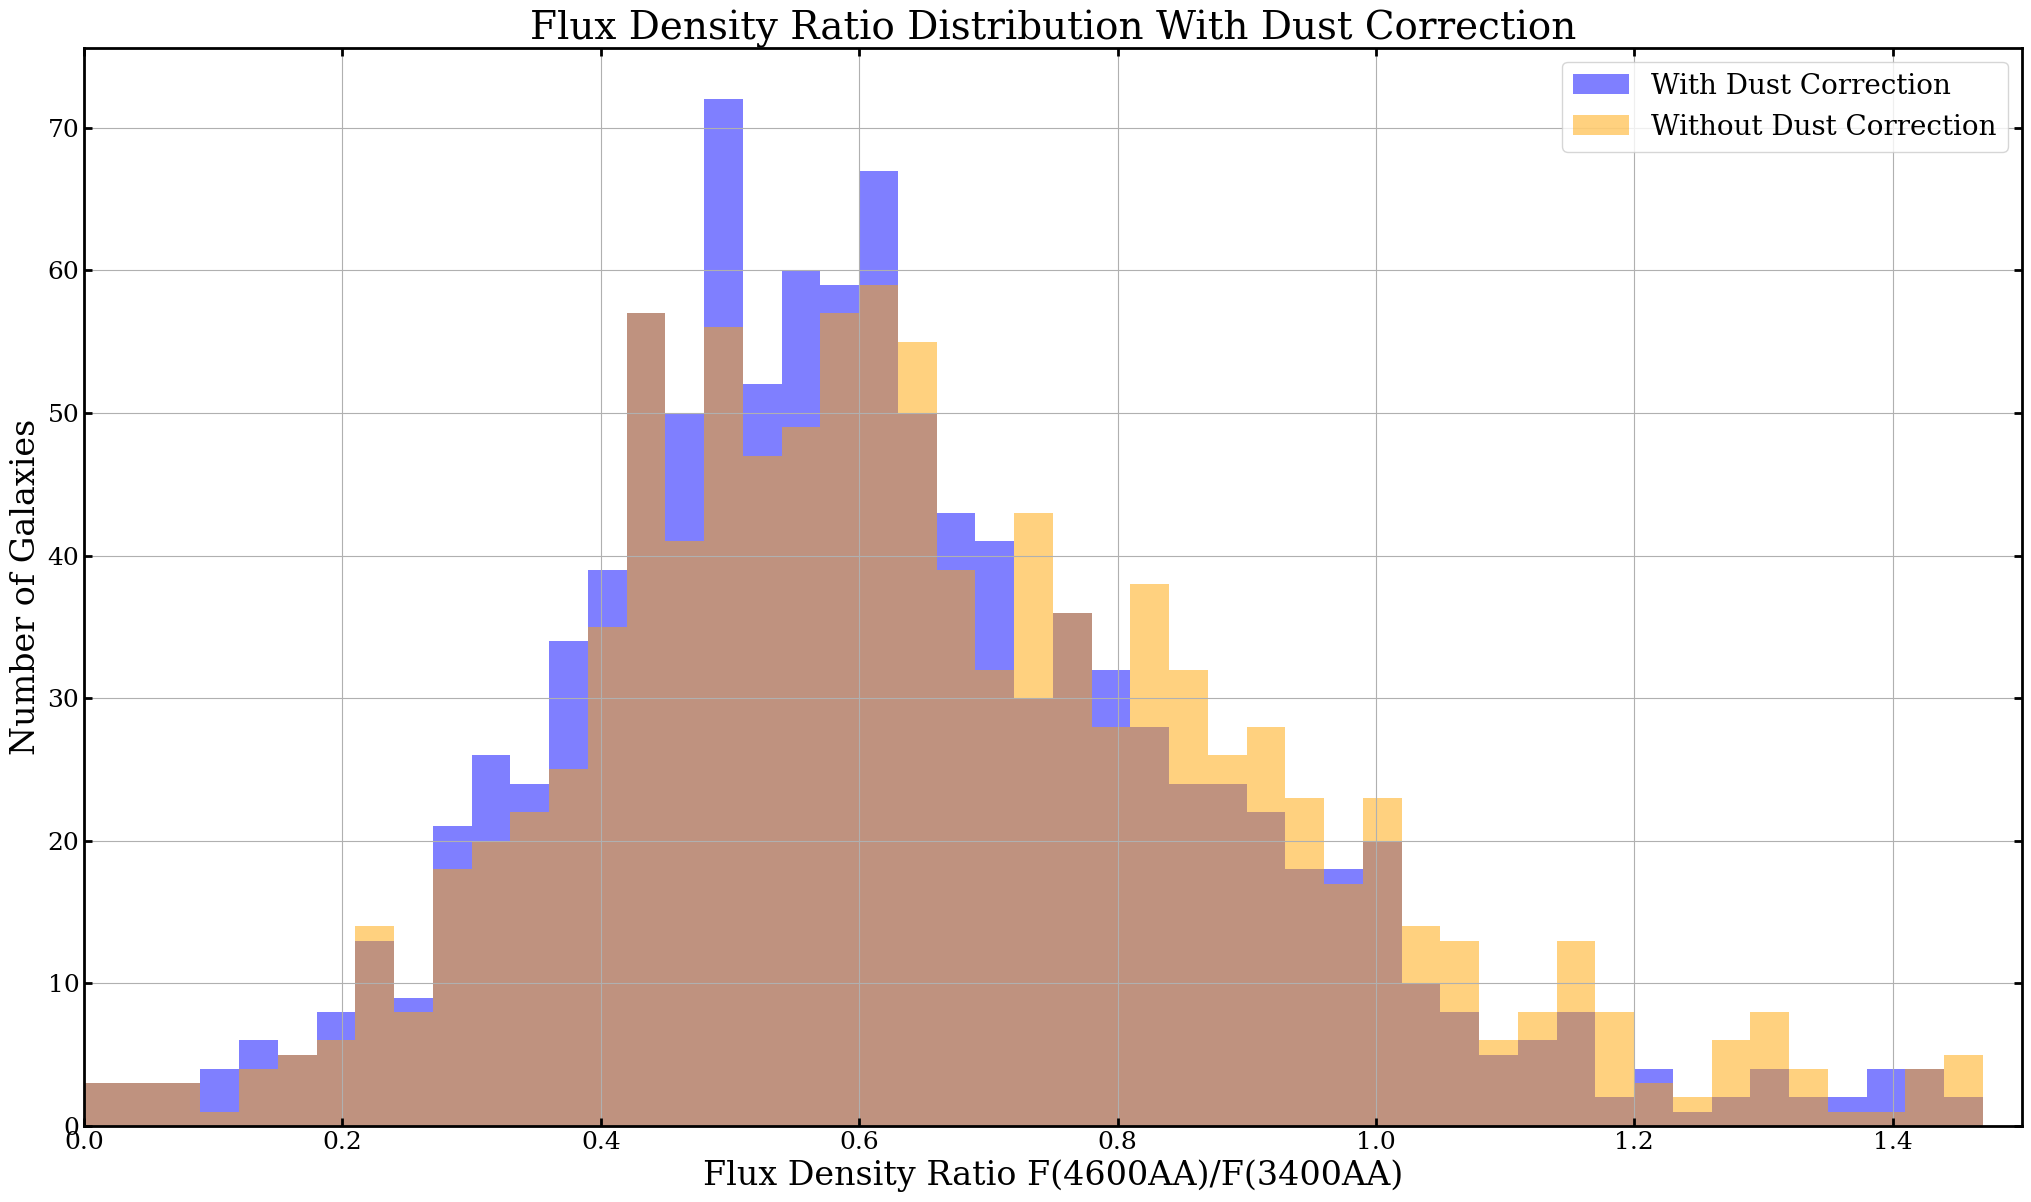

In [31]:
plt.hist(Corrected_Flux_Ratio, bins=50,range=(0,1.5),alpha=0.5, color='blue',histtype='barstacked',label='With Dust Correction')
plt.hist(No_Correction, bins=50,range=(0,1.5),alpha=0.5, color='orange',histtype='barstacked',label='Without Dust Correction')
plt.xlabel('Flux Density Ratio F(4600AA)/F(3400AA)')
plt.ylabel('Number of Galaxies')
plt.title('Flux Density Ratio Distribution With Dust Correction')
plt.legend()
plt.xlim(0,1.5)
plt.grid()
plt.savefig('Flux_Density_Ratio_Distribution_With_Dust_Correction.pdf', dpi=300)
plt.show()

In [ ]:
for i in np.where(np.array(flux_ratio)>2)[0]:

    spectrum=FL.Load_Spectrum_From_Fits(DJAv4Catalog.catalog[survey_id_subid_list[i]]['prism_filepath'],DJAv4Catalog.catalog[survey_id_subid_list[i]]['determined_redshift'])
    fig,ax=spectrum.show(if_show=False,flux_type='flambda')
    ax.set_xlim(1250,7000)
    plt.show()

In [ ]:
for i in np.where(np.array(flux_ratio)<0.1)[0]:

    spectrum=FL.Load_Spectrum_From_Fits(DJAv4Catalog.catalog[survey_id_subid_list[i]]['prism_filepath'],DJAv4Catalog.catalog[survey_id_subid_list[i]]['determined_redshift'])
    fig,ax=spectrum.show(if_show=False,flux_type='flambda')
    spectrum.set_boundarys(1250*u.AA,6000*u.AA)
    ax.set_xlim(1250,7000)
    ax.set_ylim(np.nanmax(spectrum.processing_flux_lambda.data)*-0.1, np.nanmax(spectrum.processing_flux_lambda.data)*1.1)
    ax.set_title(f'Flux Ratio F(4600AA)/F(3400AA)={flux_ratio[i]:.2f}')
    plt.show()

In [10]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_ratio_list=[]
balmer_ratio_err_list=[]
plotting_alpha_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    best_SNR=-1
    best_Signal=None
    best_Noise=None
    best_key=None
    for key, dict_value in catalog['lines_fit'].items():

        balmer_decrement_uncertainty=FL.BalmerDecrementUncertainty(dict_value['halpha_flux'],dict_value['halpha_flux_err'],dict_value['hbeta_flux'],dict_value['hbeta_flux_err'])
        balmer_decrement=dict_value['halpha_flux']/dict_value['hbeta_flux']
        snr=abs(balmer_decrement/balmer_decrement_uncertainty)
        if snr>best_SNR:
            best_SNR=snr
            best_Signal=balmer_decrement
            best_Noise=balmer_decrement_uncertainty
            best_key=key
    if best_Signal is None:
        catalog['dust_curve_parameters']={}
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('No valid Balmer decrement measurement')
        DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)
        continue

    balmer_ratio_list.append(best_Signal)
    balmer_ratio_err_list.append(best_Noise)
    catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']={key: catalog['lines_fit'][best_key][key] for key in catalog['lines_fit'][best_key].keys()}
    DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)

    uv_slope_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent'])
    uv_slope_err_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent_error'])

    if np.log(best_Signal/2.86)<-0.2:
        plotting_alpha_list.append(0.3)
    else:
        plotting_alpha_list.append(1.0)


uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)
balmer_ratio_array=np.array(balmer_ratio_list)
balmer_ratio_err_array=np.array(balmer_ratio_err_list)

balmer_decrement_array=np.log(balmer_ratio_array/(2.86))
balmer_decrement_uncertainty_array=balmer_ratio_err_array/balmer_ratio_array

In [11]:
Corrected_Flux_Ratio=np.array(Corrected_Flux_Ratio)
uv_slope_array=np.array(uv_slope_array)

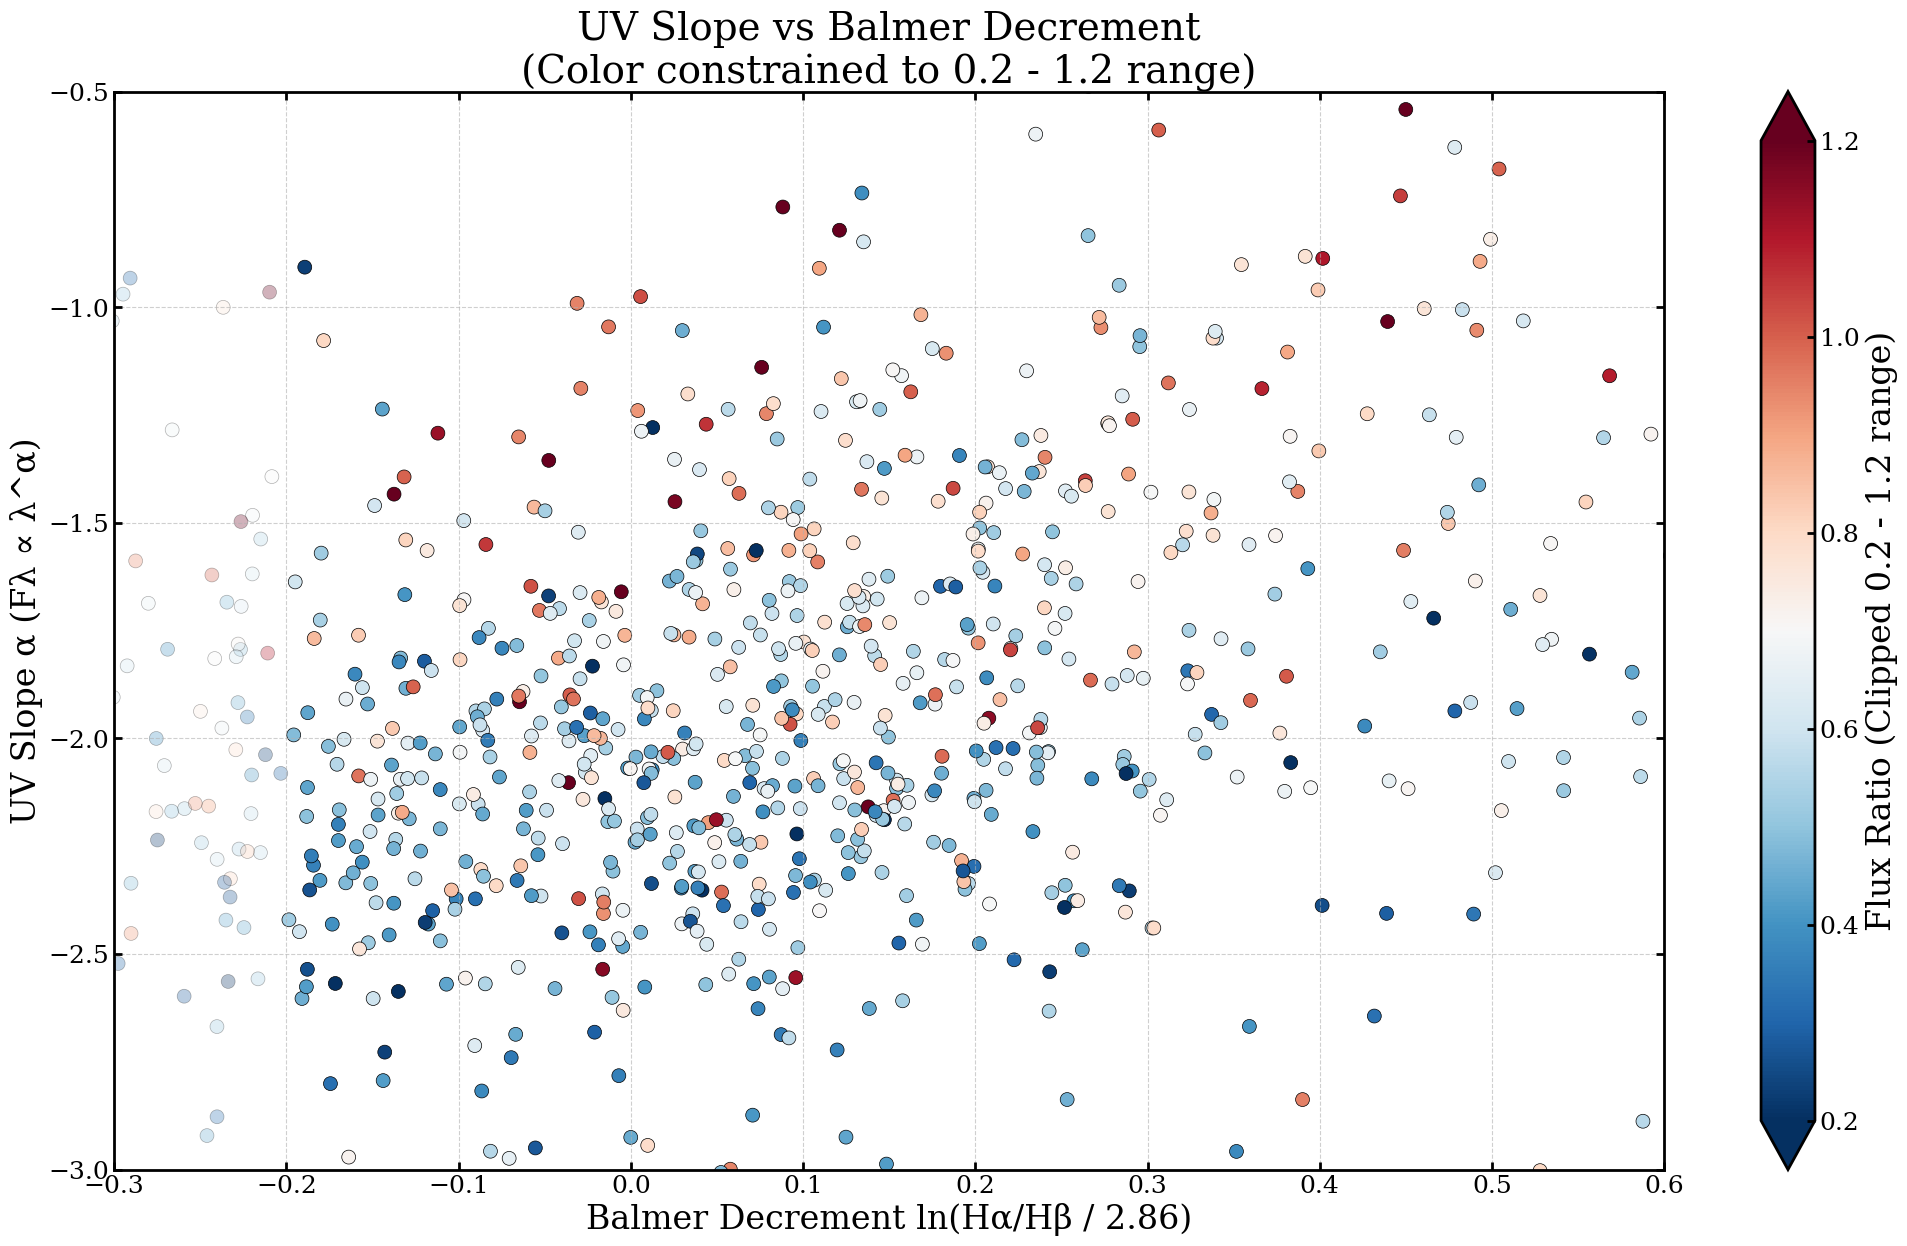

In [12]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=Corrected_Flux_Ratio,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=0.2,       # <--- 强制颜色映射下限
                      vmax=1.2,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=np.array(plotting_alpha_list),
                      edgecolor='k',
                      linewidth=0.5)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Flux Ratio (Clipped 0.2 - 1.2 range)')

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 0.2 - 1.2 range)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
plt.savefig('UV_Slope_vs_Balmer_Decrement_Correction_Clipped_0.2_1.2.pdf', bbox_inches='tight', dpi=300)
plt.show()

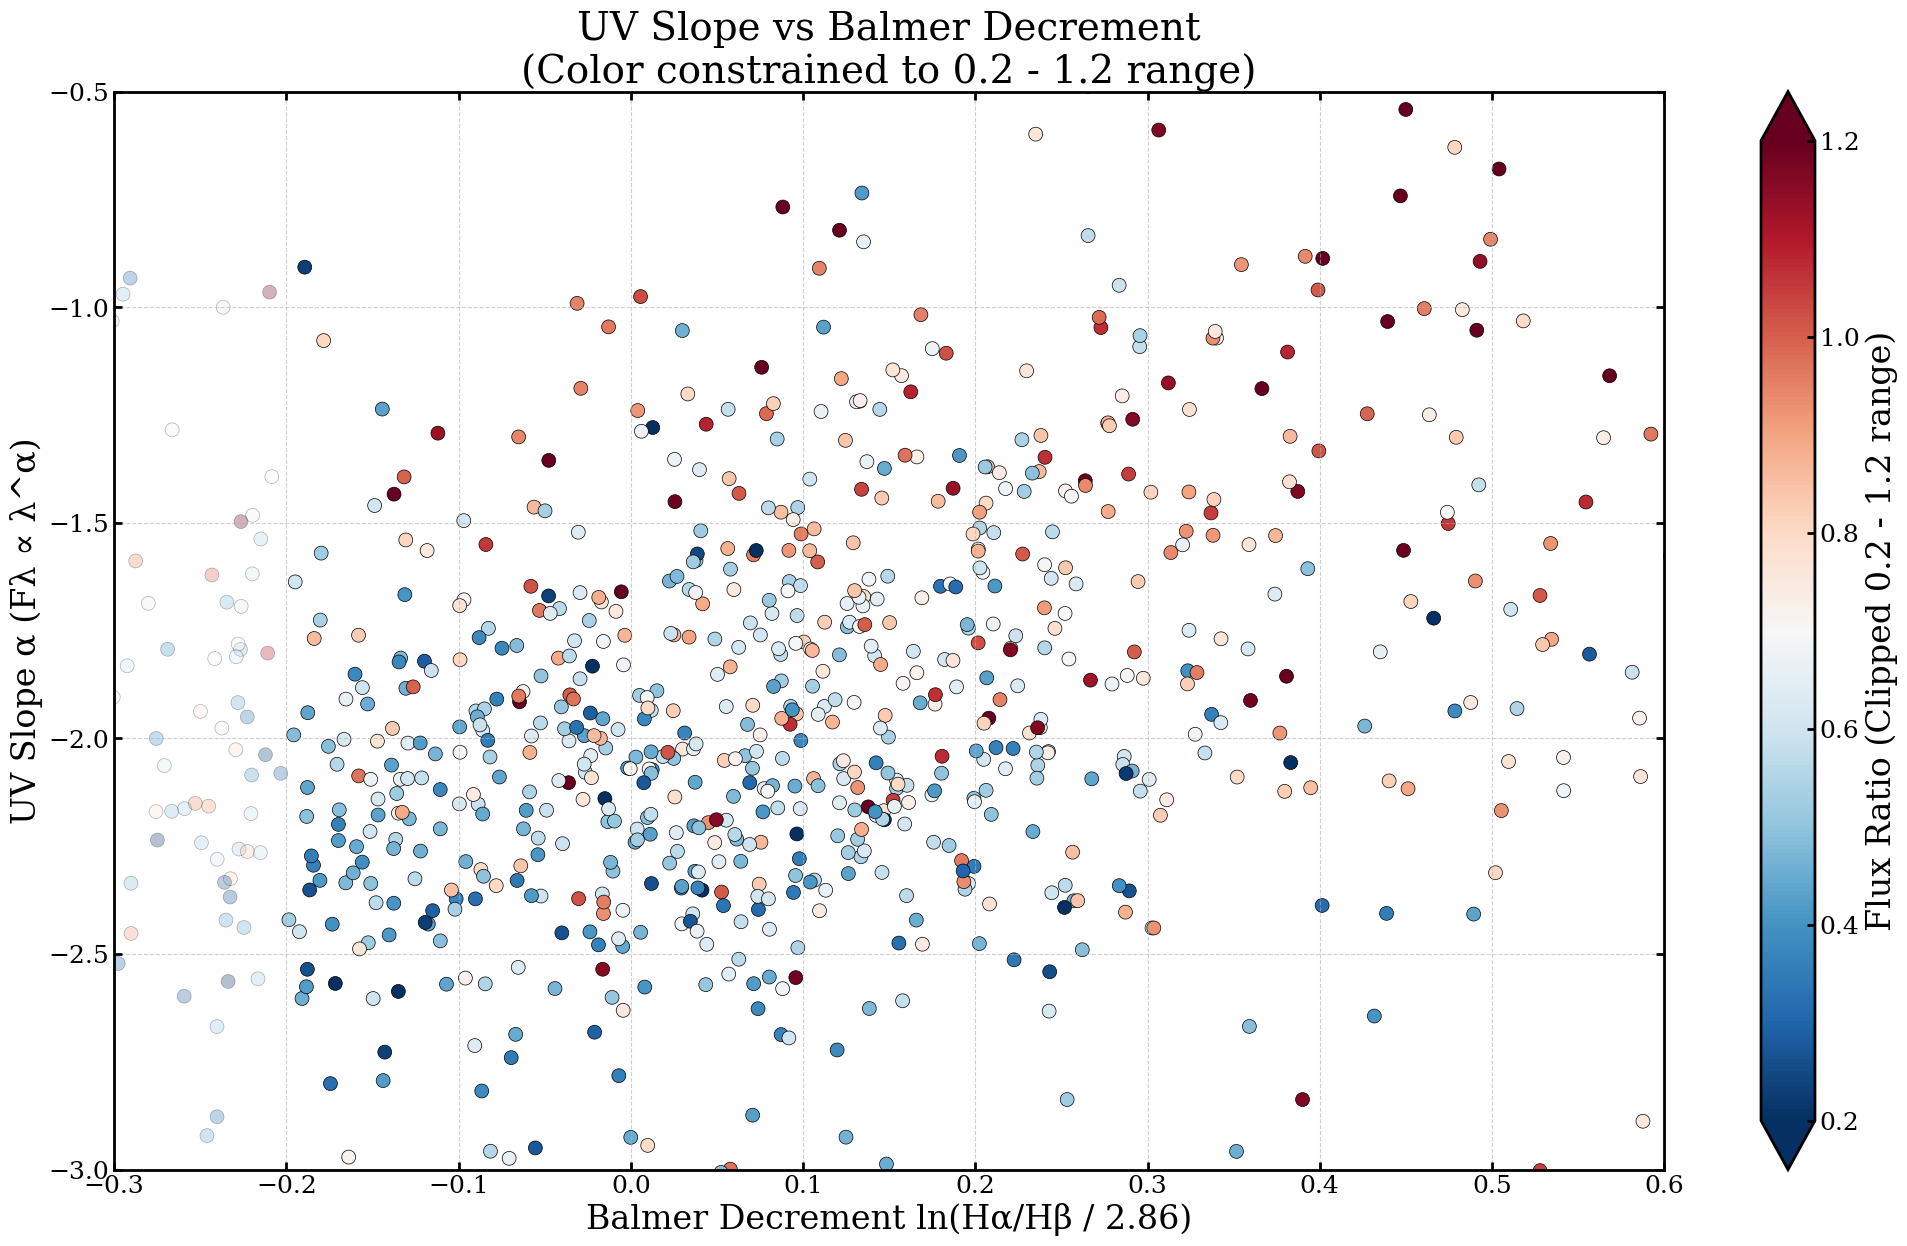

In [57]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=No_Correction,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=0.2,       # <--- 强制颜色映射下限
                      vmax=1.2,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=np.array(plotting_alpha_list),
                      edgecolor='k',
                      linewidth=0.5)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Flux Ratio (Clipped 0.2 - 1.2 range)')

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 0.2 - 1.2 range)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
plt.savefig('UV_Slope_vs_Balmer_Decrement_No_Correction_Clipped_0.2_1.2.pdf', bbox_inches='tight', dpi=300)
plt.show()

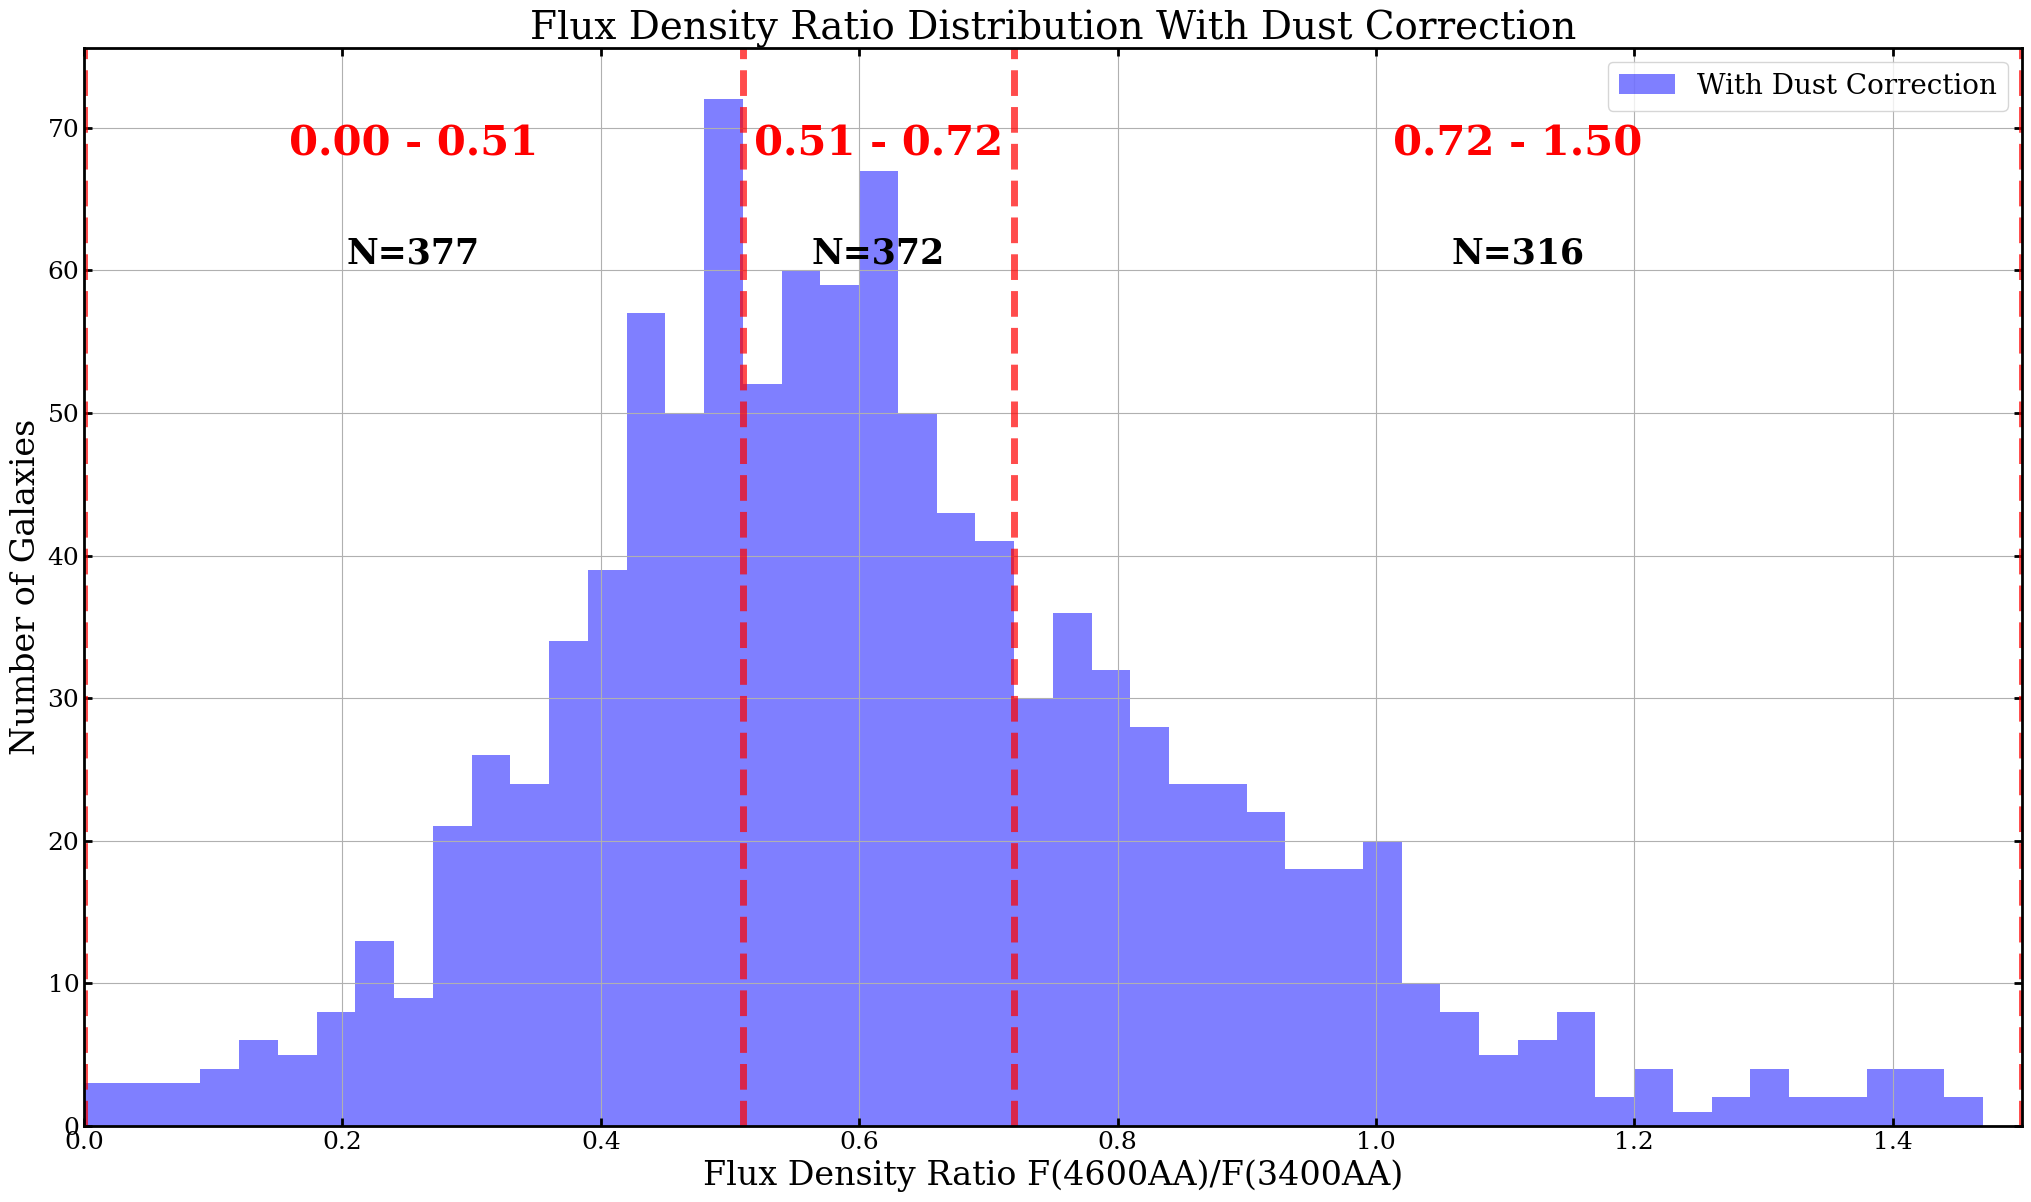

In [13]:

boundarys=np.array([0,0.51,0.72,1.5])
plt.figure(figsize=(25, 14))
plt.hist(Corrected_Flux_Ratio, bins=50,range=(0,1.5),alpha=0.5, color='blue',histtype='barstacked',label='With Dust Correction')
for b in boundarys:
    plt.axvline(b, color='red', linestyle='--', alpha=0.7,linewidth=5)

for b in boundarys[:-1]:
    plt.text((b+boundarys[np.where(boundarys==b)[0][0]+1])/2, plt.ylim()[1]*0.9, f'{b:.2f} - {boundarys[np.where(boundarys==b)[0][0]+1]:.2f}', color='red', fontsize=30, ha='center', weight='bold')
    plt.text((b+boundarys[np.where(boundarys==b)[0][0]+1])/2, plt.ylim()[1]*0.8, f'N={np.sum((Corrected_Flux_Ratio>=b) & (Corrected_Flux_Ratio<boundarys[np.where(boundarys==b)[0][0]+1]))}', color='black', fontsize=25, ha='center', weight='bold')
plt.xlabel('Flux Density Ratio F(4600AA)/F(3400AA)')
plt.ylabel('Number of Galaxies')
plt.title('Flux Density Ratio Distribution With Dust Correction')
plt.legend()
plt.xlim(0,1.5)
plt.grid()
plt.savefig('Age_Binning.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
alpha_list=[]
for ratio in Corrected_Flux_Ratio:
    if ratio<0.51:
        alpha_list.append(1)
    elif ratio<0.72:
        alpha_list.append(0.2)
    else:
        alpha_list.append(0.2)

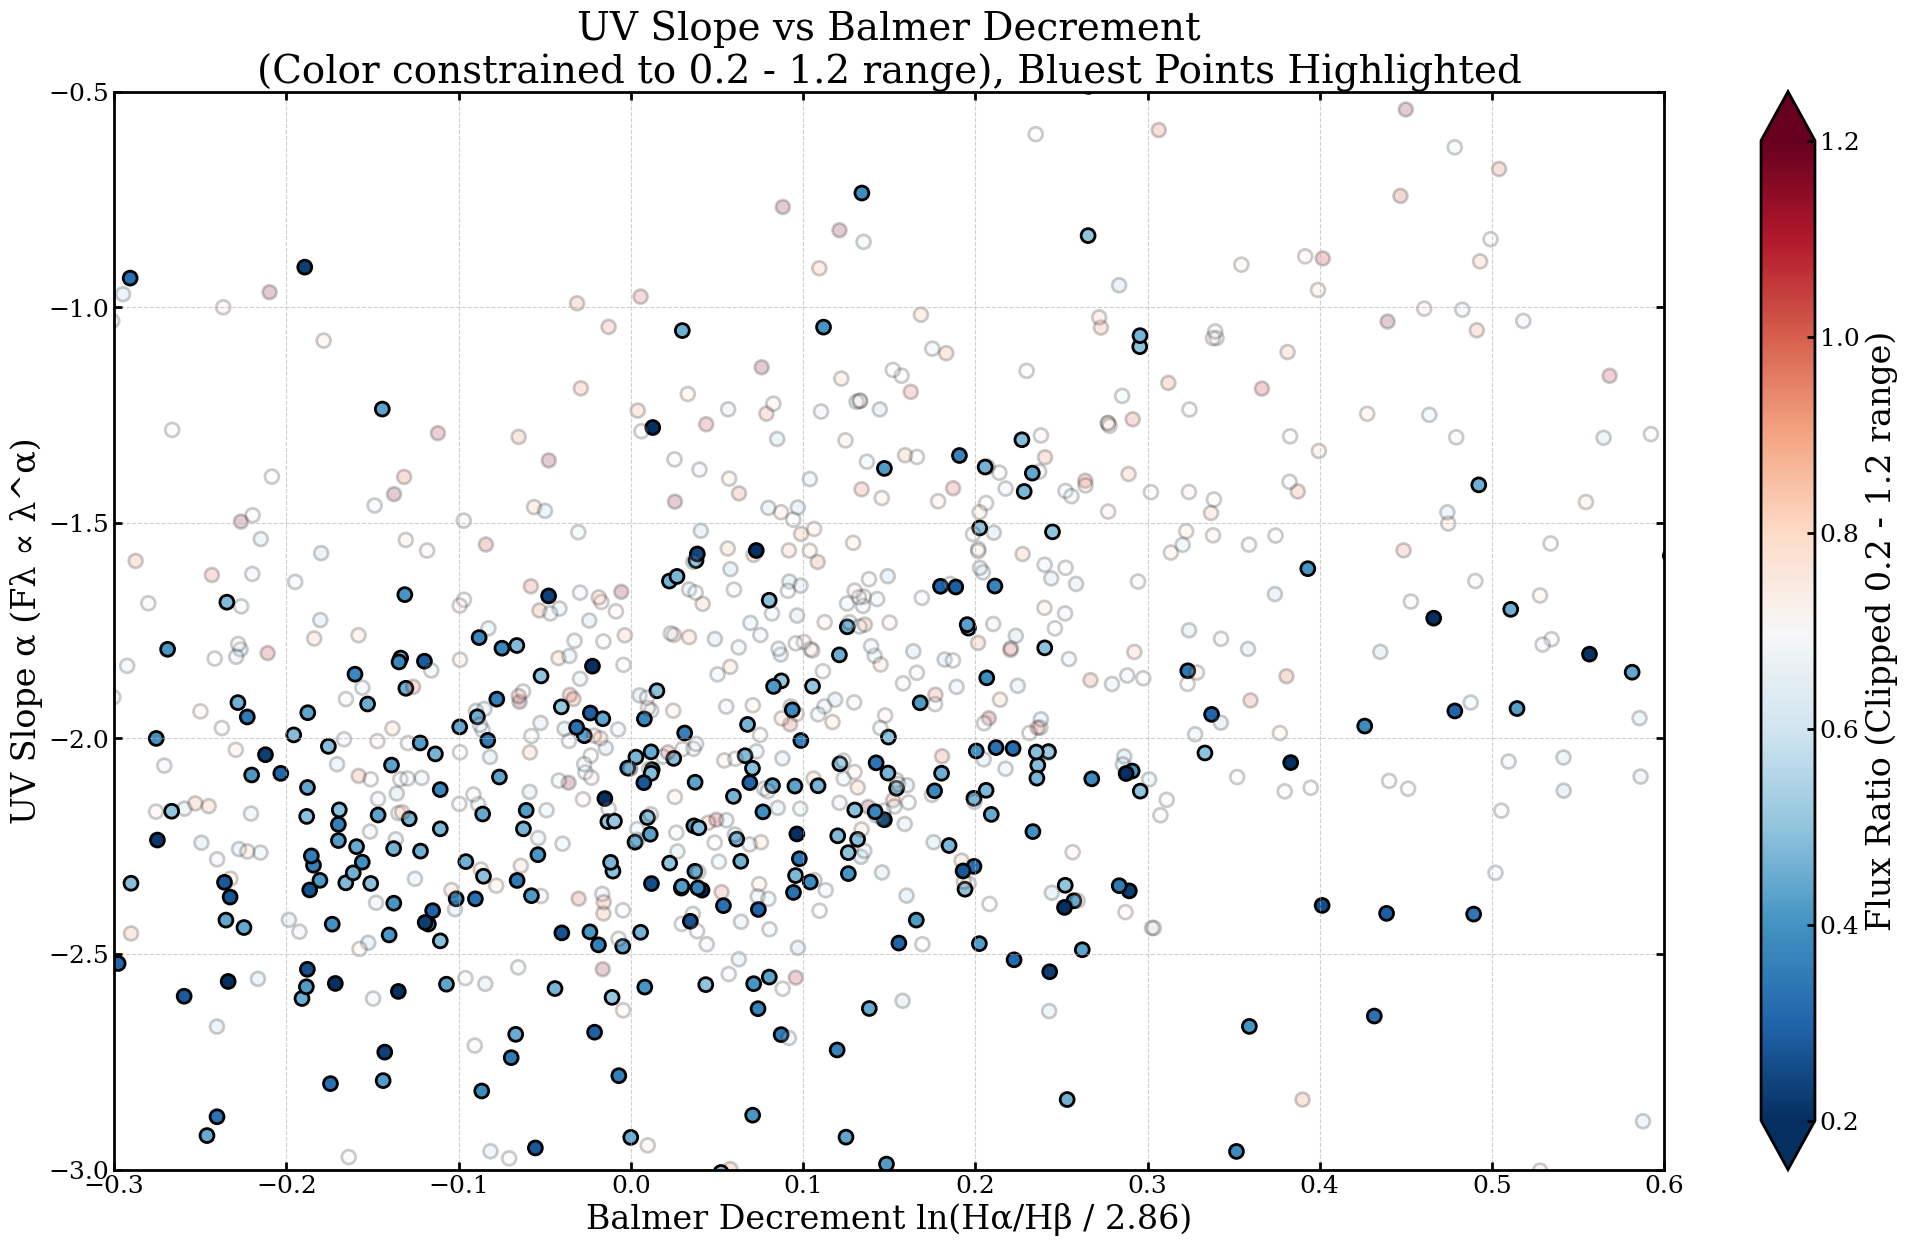

In [28]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=Corrected_Flux_Ratio,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=0.2,       # <--- 强制颜色映射下限
                      vmax=1.2,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=np.array(alpha_list),
                      edgecolor='k',
                      linewidth=2)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Flux Ratio (Clipped 0.2 - 1.2 range)')

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 0.2 - 1.2 range), Bluest Points Highlighted')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
plt.savefig('Bluest_Points.pdf', bbox_inches='tight', dpi=300)
plt.show()